# Optimizing hyperparameters

In [1]:
# imports
import mne
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split, cross_val_score 
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm
import pickle

# utils functions
from utils.preprocessing import load_complete_session, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

### Time intervals (feature extraction)

#### function

In [2]:
# change range of arange from 0.1,0.51 to 0.1,0.81 (bc in the Musso et al paper they say that the P600 is related to language)
def nested_cv(trials):
    # Time intervals
    print("Time intervals:")
    ival_bounds_100 = np.arange(0.1,0.81,0.1) # [0.1 0.2 0.3 0.4...
    print(f"100 ms: \n{ival_bounds_100}")
    ival_bounds_50 = np.arange(0.1,0.81,0.05) # [0.1  0.15 0.2  0.25 0.3...
    print(f"50 ms: \n{ival_bounds_50}")
    ival_bounds_20 = np.arange(0.1,0.81,0.02) # [0.1  0.12 0.14 ... 
    print(f"20 ms: \n{ival_bounds_20}")
    ival_bounds_10 = np.arange(0.12,0.8,0.01) # [0.12 0.13 0.14 ...
    print(f"10 ms: \n{ival_bounds_10}")

    # Nested cv settings
    ival_grid = [
                ival_bounds_100, 
                ival_bounds_50, 
                ival_bounds_20, 
                ival_bounds_10
                ]
    n_trials = len(trials)
    K_folds = 4
    fold_size = int(n_trials/K_folds)

    print(f"\nn_trials: {len(trials)}")
    print(f"Doing a {K_folds}-fold cross-vaidation:")
    print(f"There are {K_folds} folds each of size: {fold_size}")

    print("\nPerforming cross-validation...")

    ival_counter = 0
    ival_list = [100, 50, 20, 10]
    all_ival_scores = dict()

    for ival in ival_grid:
        outer_kf = KFold(n_splits=K_folds, shuffle=False)
        scores = np.zeros(4)
        nch = (trials[0][0]).info["nchan"]
        fold_counter = 0

        #for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(tqdm(outer_kf.split(trials), total=K_outer_folds, desc="CV")):
        for train_idx, test_idx in outer_kf.split(trials):

            X_train = [trials[i] for i in train_idx]  # | |x|x|x| for fold 1, |x| |x|x| for fold 2, ...
            X_test = [trials[i] for i in test_idx]    # |x| | | | for fold 1, | |x| | | for fold 2, ...

            # OUTER TEST using best ival
            X_train_complete, y_train_complete = epoch_vectorizer_channelprime(X_train,ival)
            X_test_complete, y_test_complete = epoch_vectorizer_channelprime(X_test, ival)

            # classifier
            clf_btlda_final = make_pipeline(
                ToeplitzLDA(n_channels=nch),
            )
            clf_btlda_final.fit(X_train_complete,y_train_complete)
            y_scores_test = clf_btlda_final.decision_function(X_test_complete)

            fold_score = roc_auc_score(y_test_complete, y_scores_test)
            scores[fold_counter] = fold_score
            fold_counter+=1

        print(f"\n Ival {ival_list[ival_counter]} ms")
        print(f"All folds scores: {scores}")
        print(f"Average AUC over all folds: {np.mean(scores):.4f}")
        all_ival_scores.update({f"{ival}":scores})
        ival_counter+=1
        
    return all_ival_scores



#### Run procedure

In [3]:
# runtime: 7 mins
# Procedure: cross-validation for all patients

all_patient_results = dict() 

# for all patients
for i in range(1,10):
    print(f"Patient {i} -----------------------------------")
    # load data of sessions 1 and 2
    data_s1 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S1/anonymized", 
                               selection = "6D_long_350", 
                               discard_channels=True)
    data_s2 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S2/anonymized", 
                                selection = "6D_long_350", 
                                discard_channels=True)
    data_s12 = merge_sessions(data_s1, data_s2)
    trials = data_s12.get('trials')

    # perform nested cv
    outer_results = nested_cv(trials)

    # store results
    all_patient_results[f'P{i}_6D_long_350'] = outer_results

# patient 10:
print(f"Patient {10} -----------------------------------")
# load data of sessions 1 and 2
data_s1 = load_session_chached(f"B:/anonymized_data/P10a/P10_S1/anonymized", 
                            selection = "6D_long_350", 
                            discard_channels=True)
data_s2 = load_session_chached(f"B:/anonymized_data/P10a/P10_S2/anonymized", 
                            selection = "6D_long_350", 
                            discard_channels=True)
data_s12 = merge_sessions(data_s1, data_s2)
trials = data_s12.get('trials')

# perform nested cv
outer_results = nested_cv(trials)

# store results
all_patient_results[f'P10_6D_long_350'] = outer_results

Patient 1 -----------------------------------
Loading file:  B:_anonymized_data_P01a_P1_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P01a_P1_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
Time intervals:
100 ms: 
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
50 ms: 
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8 ]
20 ms: 
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64
 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8 ]
10 ms: 
[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25
 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.

In [5]:
print(all_patient_results.keys())
print(all_patient_results.get("P1_6D_long_350").keys())
results = np.zeros((10,4))
p_nr = 0
for p in all_patient_results.keys():
    patient = all_patient_results.get(p)
    ival_nr = 0
    for time_ival in patient.keys():
        print("{:0.2f}: {}".format((1/len(time_ival[:]))*23,(patient.get(time_ival))))
        print(np.mean(patient.get(time_ival)))
        results[p_nr, ival_nr] = np.mean(patient.get(time_ival))
        ival_nr += 1
    p_nr += 1
    

dict_keys(['P1_6D_long_350', 'P2_6D_long_350', 'P3_6D_long_350', 'P4_6D_long_350', 'P5_6D_long_350', 'P6_6D_long_350', 'P7_6D_long_350', 'P8_6D_long_350', 'P9_6D_long_350', 'P10_6D_long_350'])
dict_keys(['[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]', '[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75\n 0.8 ]', '[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36\n 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64\n 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8 ]', '[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25\n 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39\n 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53\n 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67\n 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79]'])
0.70: [0.57136111 0.61029167 0.56380952 0.59597279]
0.585358772675737
0.30: [0.56820833 0.60326389 0.57473016 0.62156916]
0.5919428854

In [6]:
print(results)
np.save('max_800_btlda_ivals_cv.npy',results, allow_pickle=True)

[[0.58535877 0.59194289 0.58543637 0.57893785]
 [0.63015741 0.63833333 0.61855247 0.61551235]
 [0.86373388 0.86993141 0.86531962 0.86430727]
 [0.57571032 0.5668891  0.56003444 0.55995309]
 [0.8543444  0.85946104 0.85855694 0.85643719]
 [0.86485048 0.87472977 0.87738546 0.87528669]
 [0.62929819 0.63780237 0.62989895 0.61988265]
 [0.65739918 0.68097119 0.68386831 0.68928121]
 [0.55395885 0.54999451 0.53503978 0.52924554]
 [0.50287967 0.50062638 0.49872228 0.49707184]]


Grand average of 100 ms: 0.6717691143845225
Grand average of 50 ms: 0.6770681984194746
Grand average of 20 ms: 0.6712814620667906
Grand average of 10 ms: 0.6685915689516675


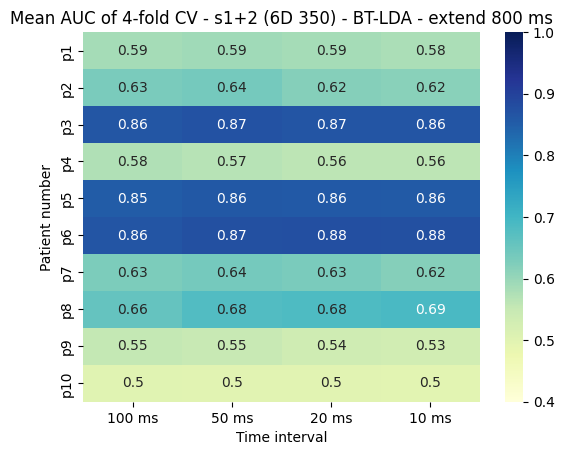

In [7]:
# Results

import seaborn as sns

# Histogram 1 --------------------------------------

# all_scores = []
# for patient in all_patient_results.keys():
#     patient_list = []
#     for fold in all_patient_results.get(patient):
#         patient_list.append(fold.get('score'))
#     all_scores.append(patient_list)

sns.heatmap(results,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC of 4-fold CV - s1+2 (6D 350) - BT-LDA - extend 800 ms")

# Print results
#print(fold_means_array.shape)
print(f"Grand average of 100 ms: {np.mean(results, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(results, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(results, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(results, axis=0)[3]}")



# # Histogram 2 --------------------------------------

# all_folds_list = []
# for patient in all_patient_results.keys():
#     fold_list = []
#     for fold in all_patient_results.get(patient):
#         fold_list.append(((fold.get('best_ival')[1] - fold.get('best_ival')[0])))
#     all_folds_list.append(fold_list)

# sns.heatmap(all_folds_list,vmin=0.01,vmax=0.15,center=0.03,annot=True,yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cbar=True, cmap="coolwarm", ax=axs[1])
# axs[1].set_xlabel("outer fold of the nested cv")
# axs[1].set_title("best time interval per fold")
# plt.suptitle("Heatmap per patient: each block is the outcome of a fold")
# plt.show()

### Shrinkage LDA

#### functions

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# change range ival from 0.1-0.51 to 0.1-0.81
def nested_cv_slda(trials):
    # Time intervals
    print("Time intervals:")
    ival_bounds_100 = np.arange(0.1,0.81,0.1) # [0.1 0.2 0.3 0.4 0.5] (4)
    print(f"100 ms: \n{ival_bounds_100}")
    ival_bounds_50 = np.arange(0.1,0.81,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5] (8)
    print(f"50 ms: \n{ival_bounds_50}")
    ival_bounds_20 = np.arange(0.1,0.81,0.02) # [0.1  0.12 0.14 ... 0.46 0.48 0.5] (20)
    print(f"20 ms: \n{ival_bounds_20}")
    ival_bounds_10 = np.arange(0.12,0.81,0.01) # [0.12 0.13 0.14 ... 0.48 0.49 0.5] # might be changed
    print(f"10 ms: \n{ival_bounds_10}")

    # Nested cv settings
    ival_grid = [
                ival_bounds_100, 
                ival_bounds_50, 
                ival_bounds_20, 
                ival_bounds_10
                ]
    n_trials = len(trials)
    K_folds = 4
    fold_size = int(n_trials/K_folds)

    print(f"\nn_trials: {len(trials)}")
    print(f"Doing a {K_folds}-fold cross-vaidation:")
    print(f"There are {K_folds} folds each of size: {fold_size}")

    print("\nPerforming cross-validation...")

    ival_counter = 0
    ival_list = [100, 50, 20, 10]
    all_ival_scores = dict()

    for ival in ival_grid:
        outer_kf = KFold(n_splits=K_folds, shuffle=False)
        scores = np.zeros(4)
        #nch = (trials[0][0]).info["nchan"]
        fold_counter = 0

        #for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(tqdm(outer_kf.split(trials), total=K_outer_folds, desc="CV")):
        for train_idx, test_idx in outer_kf.split(trials):

            X_train = [trials[i] for i in train_idx]  # | |x|x|x| for fold 1, |x| |x|x| for fold 2, ...
            X_test = [trials[i] for i in test_idx]    # |x| | | | for fold 1, | |x| | | for fold 2, ...

            # OUTER TEST using best ival
            X_train_complete, y_train_complete = epoch_vectorizer_channelprime(X_train,ival)
            X_test_complete, y_test_complete = epoch_vectorizer_channelprime(X_test, ival)

            # classifier
            slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),) # SLDA

            slda.fit(X_train_complete,y_train_complete)
            y_scores_test = slda.decision_function(X_test_complete)

            fold_score = roc_auc_score(y_test_complete, y_scores_test)
            scores[fold_counter] = fold_score
            fold_counter+=1

        print(f"\n Ival {ival_list[ival_counter]} ms")
        print(f"All folds scores: {scores}")
        print(f"Average AUC over all folds: {np.mean(scores):.4f}")
        all_ival_scores.update({f"{ival}":scores})
        ival_counter+=1
        
    return all_ival_scores



In [9]:
# Procedure: cross-validation for all patients

all_patient_results_slda = dict() 

# for all patients
for i in range(1,11):
    print(f"Patient {i} -----------------------------------")
    # load data of sessions 1 and 2
    if i<10:
        data_s1 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S1/anonymized", 
                                selection = "6D_long_350", 
                                discard_channels=True)
        data_s2 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S2/anonymized", 
                                    selection = "6D_long_350", 
                                    discard_channels=True)
        
    else:
        data_s1 = load_session_chached(f"B:/anonymized_data/P{i}a/P{i}_S1/anonymized", 
                                selection = "6D_long_350", 
                                discard_channels=True)
        data_s2 = load_session_chached(f"B:/anonymized_data/P{i}a/P{i}_S2/anonymized", 
                                    selection = "6D_long_350", 
                                    discard_channels=True)   
         
    data_s12 = merge_sessions(data_s1, data_s2)
    trials = data_s12.get('trials')

    # perform nested cv
    outer_results = nested_cv_slda(trials)

    # store results
    all_patient_results_slda[f'P{i}_6D_long_350'] = outer_results


Patient 1 -----------------------------------
Loading file:  B:_anonymized_data_P01a_P1_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P01a_P1_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
Time intervals:
100 ms: 
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
50 ms: 
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8 ]
20 ms: 
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64
 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8 ]
10 ms: 
[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25
 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.

In [10]:
print(all_patient_results_slda.keys())
print(all_patient_results_slda.get("P1_6D_long_350").keys())
results = np.zeros((10,4))
p_nr = 0
for p in all_patient_results_slda.keys():
    patient = all_patient_results_slda.get(p)
    ival_nr = 0
    for time_ival in patient.keys():
        print("{:0.2f}: {}".format((1/len(time_ival[:]))*23,(patient.get(time_ival))))
        print(np.mean(patient.get(time_ival)))
        results[p_nr, ival_nr] = np.mean(patient.get(time_ival))
        ival_nr += 1
    p_nr += 1
    

dict_keys(['P1_6D_long_350', 'P2_6D_long_350', 'P3_6D_long_350', 'P4_6D_long_350', 'P5_6D_long_350', 'P6_6D_long_350', 'P7_6D_long_350', 'P8_6D_long_350', 'P9_6D_long_350', 'P10_6D_long_350'])
dict_keys(['[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]', '[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75\n 0.8 ]', '[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36\n 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64\n 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8 ]', '[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25\n 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39\n 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53\n 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67\n 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8 ]'])
0.70: [0.57247222 0.61956944 0.5878458  0.59972789]
0.5949038407029478
0.30: [0.56216667 0.59908333 0.59940136 0.62374603]
0.5960

In [ ]:
print(results)

#### Results

In [11]:
print(results)
np.save('max_800_slda_ivals_cv.npy',results, allow_pickle=True)

[[0.59490384 0.59609935 0.5817736  0.57658022]
 [0.62127932 0.62636728 0.60745062 0.60341358]
 [0.85862826 0.86058985 0.85277641 0.84636763]
 [0.58406463 0.56878649 0.57005754 0.56710325]
 [0.85307937 0.85757663 0.85813554 0.85921175]
 [0.85564335 0.86546502 0.86360768 0.85982167]
 [0.61807929 0.62519182 0.6140946  0.60946677]
 [0.65100686 0.66996159 0.67052126 0.67632099]
 [0.56115775 0.55631276 0.54590947 0.53900686]
 [0.50506605 0.50184724 0.49497711 0.49257361]]


Grand average of 100 ms: 0.6702908720859402
Grand average of 50 ms: 0.6728198031587007
Grand average of 20 ms: 0.6659303825781742
Grand average of 10 ms: 0.6629866314079743


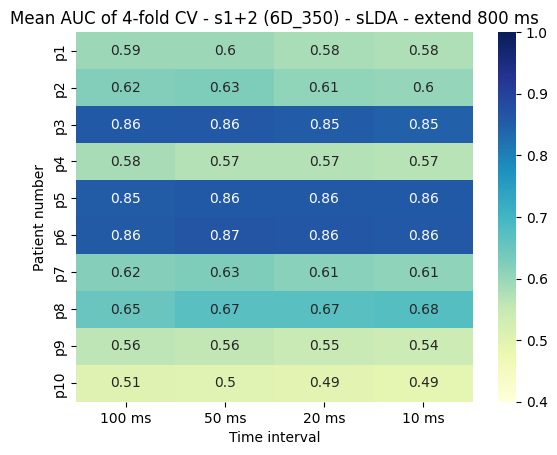

In [13]:
# Results

import seaborn as sns

# Histogram 1 --------------------------------------

sns.heatmap(results,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC of 4-fold CV - s1+2 (6D_350) - sLDA - extend 800 ms")

# Print results
#print(fold_means_array.shape)
print(f"Grand average of 100 ms: {np.mean(results, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(results, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(results, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(results, axis=0)[3]}")



# # Histogram 2 --------------------------------------

# all_folds_list = []
# for patient in all_patient_results.keys():
#     fold_list = []
#     for fold in all_patient_results.get(patient):
#         fold_list.append(((fold.get('best_ival')[1] - fold.get('best_ival')[0])))
#     all_folds_list.append(fold_list)

# sns.heatmap(all_folds_list,vmin=0.01,vmax=0.15,center=0.03,annot=True,yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cbar=True, cmap="coolwarm", ax=axs[1])
# axs[1].set_xlabel("outer fold of the nested cv")
# axs[1].set_title("best time interval per fold")
# plt.suptitle("Heatmap per patient: each block is the outcome of a fold")
# plt.show()